[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vkoul/ab-test-practice/blob/main/solutions/w02_handling_test_validity_threats.ipynb)

> **Run this notebook interactively:** Click the badge above to open in Google Colab.

# A/B Testing in Practice: Project 2


## Background

Welcome back to **FamilyNest**, you extraordinary product data scientist! It’s been a few months, and you and your team are rolling now! Carrying over from the work you did last week- the team is sticking with new booked listings as the target metric, new cancelled listings as the guardrail, and new active listings as an informative metric.

This time, four A/B tests need to be designed and analyzed. There may be some surprising results, so be sure to analyze the results carefully! The test data is simulated, but that doesn't mean that we've simulated a flawless run of the test. If you're surprised by your results, think carefully about what could have caused them.

Note that for analysis, we are now providing some segmentation information about each user: continent, device, and if they have been a host on FamilyNest before. This information will be helpful for some of the tests but not all.

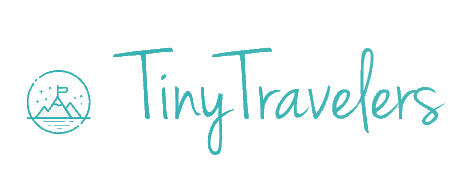

## Setup

Load data into Google Collab (skip this block if you are running it outside collab).

In [ ]:
!pip install -U --no-cache-dir gdown --pre
!gdown --no-cookies --fuzzy https://drive.google.com/file/d/1ptzdCxCEW4bEzBE5DLI0umreuW9BO-qa/view?usp=sharing
!gdown --no-cookies --fuzzy https://drive.google.com/file/d/1PupTTZrRdFfBtoyGW-Pg36ykcvE5nLHS/view?usp=sharing
!gdown --no-cookies --fuzzy https://drive.google.com/file/d/1NhIIosY9rHS0I1iZzLXAqjYqlJ_AcfcB/view?usp=sharing
!gdown --no-cookies --fuzzy https://drive.google.com/file/d/15yJE1nHXQs-bRmXbIxzTeB753H8jNyzx/view?usp=sharing


Downloading...
From: https://drive.google.com/uc?id=1ptzdCxCEW4bEzBE5DLI0umreuW9BO-qa
To: /content/dataset_upload_photos.csv
100% 218k/218k [00:00<00:00, 59.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1PupTTZrRdFfBtoyGW-Pg36ykcvE5nLHS
To: /content/dataset_split_page.csv
100% 5.61M/5.61M [00:00<00:00, 134MB/s]
Downloading...
From: https://drive.google.com/uc?id=1NhIIosY9rHS0I1iZzLXAqjYqlJ_AcfcB
To: /content/dataset_default_calendar.csv
100% 4.12M/4.12M [00:00<00:00, 149MB/s]
Downloading...
From: https://drive.google.com/uc?id=15yJE1nHXQs-bRmXbIxzTeB753H8jNyzx
To: /content/dataset_africa_map.csv
100% 9.93M/9.93M [00:00<00:00, 208MB/s]


Import libraries

In [ ]:
# Lirbary basics
import numpy as np
import pandas as pd
import scipy.stats as stats # For pvalue

# For markdown display
from IPython.display import Image

Helper function to get the 95% confidence interval. Inputs:
* Mean treatment - average conversion rate of the treatment group
* Mean control - average conversion rate of the control group
* N treatment - number of samples in the treatment group
* N control - number of samples in the control group
* ci = The width of the confidence interval. 0.95 by default

You can read more about the math behind the confidence interval function [here](https://s3.amazonaws.com/assets.datacamp.com/production/course_6165/slides/chapter4.pdf).

In [ ]:
def get_ci(mean_treatment, mean_control, n_treatment, n_control, ci = 0.95):
    sd = ((mean_treatment * (1 - mean_treatment)) / n_treatment + (mean_control * (1 - mean_control)) / n_control)**0.5
    lift = mean_treatment - mean_control
    val = stats.norm.isf((1 - ci) / 2)
    lwr_bnd = lift - val * sd
    upr_bnd = lift + val * sd
    return((lwr_bnd, upr_bnd))

Helper function to calcuate the results. It will compute and return the relative and absolute lift between variant and control, p-value, and lower and upper bound for the 95% confidence interval. A standard two-sided t-test with an assumption of equal variance is used to compute the p-value.

Inputs:
* DF = data frame with each row being a sample in the A/B test. It must have a column called "variant" that takes on the value "control" or "treatment
* Metric = the metric we want to evaluate. This must be 'new_active_listings','new_booked_listings', or 'new_cancelled_listings'). If it is not one of these values an "invalid metric" error will be thrown.

In [ ]:
def calculate_results(df,metric):
    # Check
    if metric not in ('new_active_listing','new_booked_listing','new_cancelled_listing'):
        raise Exception("Invalid metric")

    # Values and relative difference
    mean_control = df.loc[df['variant'] == "control",metric].mean()
    mean_treatment = df.loc[df['variant'] == "treatment",metric].mean()

    abs_diff = mean_treatment-mean_control
    rel_diff = (mean_treatment-mean_control)/mean_control

    # P-Value -- two-sided ttest, assumes normal distribution
    data_group1 = list(df.query('variant == "control"')[metric])
    data_group2 = list(df.query('variant == "treatment"')[metric])

    results = stats.ttest_ind(a=data_group1, b=data_group2, equal_var=True)
    pvaue = results.pvalue

    # 95% confidence intervals
    [ci_low, ci_high] = get_ci(mean_treatment,mean_control,len(data_group2),len(data_group1),.95)
    ci_low = ci_low/mean_control
    ci_high = ci_high/mean_control

    return(rel_diff,abs_diff,results.pvalue,ci_low,ci_high)

In [ ]:

def custom_calculate_results(df, metric, dimensions=None):
    # Check if the metric is valid
    if metric not in ('new_active_listing', 'new_booked_listing', 'new_cancelled_listing'):
        raise Exception("Invalid metric")

    results = {}
    breakdown_results = {}

    # Define a function to calculate the metrics
    def custom_calculate_metrics(df_subset):
        mean_control = df_subset.loc[df_subset['variant'] == "control", metric].mean()
        mean_treatment = df_subset.loc[df_subset['variant'] == "treatment", metric].mean()

        abs_diff = mean_treatment - mean_control
        rel_diff = (mean_treatment - mean_control) / mean_control

        # P-Value -- two-sided ttest, assumes normal distribution
        data_group1 = df_subset[df_subset['variant'] == "control"][metric]
        data_group2 = df_subset[df_subset['variant'] == "treatment"][metric]

        results = stats.ttest_ind(a=data_group1, b=data_group2, equal_var=True)
        pvalue = results.pvalue

        # 95% confidence intervals
        ci_low, ci_high = get_ci(mean_treatment, mean_control, len(data_group2), len(data_group1), 0.95)
        ci_low = ci_low / mean_control
        ci_high = ci_high / mean_control

        return rel_diff, abs_diff, pvalue, ci_low, ci_high

    # If no dimensions are given, calculate for the entire dataframe
    if not dimensions:
        results['overall'] = custom_calculate_metrics(df)
    else:
        # Calculate for each dimension
        for dimension in dimensions:
            for level in df[dimension].unique():
                df_subset = df[df[dimension] == level]
                breakdown_results[(dimension, level)] = custom_calculate_metrics(df_subset)

    # Combine overall and breakdown results
    combined_results = {'overall': results.get('overall'), 'breakdown': breakdown_results}

    return combined_results

# Example usage
# df is your dataframe, and dimensions is a list of columns to break down by
# results = custom_calculate_results(df, 'new_active_listing', dimensions=['country', 'device'])


## Task 1: Design and analyze a test - Default open calendar
Hosts start on FamilyNest with an entirely blocked calendar. Meaning they need to toggle the dates to be bookable. The team hypothesizes that new booked listings can increase if they start with a default available calendar and toggle dates to block them instead.

The UI change is shown below.

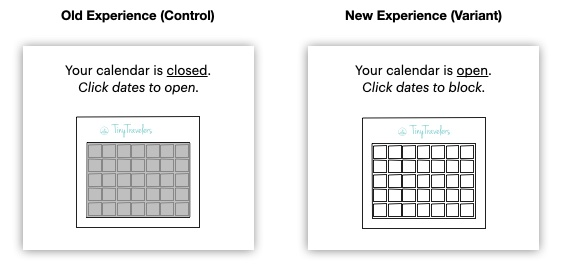

### Task 1.a. Test Design: How long should the test run and how will the launch/ no launch decision be made?

You are already a wizard at specifying triggering moments and writing hypothesis so we'll provide that for you. Here, the test should be triggered upon loading the calendar page. The hypothesis is: If we default to an available calendar in the onboarding flow, new booked listings will increase because hosts will not need to take action to be bookable.

Now the question remains: How long should the test run and how will the decision be made?

You can assume that about 5K new users arrive in the flow each day. And the cohort to book rate is 25% because the cohorting happens later in the flow when only the higher intent people are still there. You can use an online sample size calculate (e.g. Evan Miller's [sample size calculator](https://www.evanmiller.org/ab-testing/sample-size.html)). Remember, we're building on what we learned last week, so don't be afraid to look over your Week 1 project if it will help you!

## ANSWER 1.a

| Metric | Baseline Rate | Minimum Detectable Lift | Sample Size <br> Needed Per Variant | Days Needed <br> (5k daily)|
|-|-|-|-|-|
| New Booked Listings | 25% | 2% relative increase (to 25.5%) | 117,966 | 472|
| New Booked Listings | 25% | 5% relative increase (to 26.25%) | 18,929 |76|
| New Booked Listings | 25% | 10% relative increase (to 27.5%) | 4754 |20|

Assumptions:
- 80% power
- 95% confidence

Given the above results, I recommend running the test for 4 weeks (28 days) to ensure sufficient statistical power for detecting a 10% relative increase. The sample size needed to detect an MDE less than this if time is a factor in launching this feature

Decision criteria:
- Launch if new booked listings increases by 10% or more with statistical significance
- Do not launch otherwise

### Task 1.b. Test analysis

Please analyze the test and summarize the learnings and recommendations for PaM and the team below with the A/B test data provided. The data has already been cleaned for you. There is information for three milestones:

* new_active_listing - 1 if a user published their listing during experiment. Otherwise 0.
* new_booked_listing - 1 if a user received a guest booked on a new listing during the experiment. Otherwise 0.
* new_cancelled_listing - 1 if a user cancelled a new booking during the experiment. Otherwise 0.

We also provided some segmentation information for each user.
* continent - the continent for the host, either 'asia','north_america','south_america','australia','europe','africa'
* booked_previously - 1 if the host has hosted before the started the onboarding flow (because they have a home on a different platform like Airbnb).
* device - the device the host is using when starting the onboarding flow. Either 'android', 'ios' or 'web'.

Note: Only use a user segment when you have a reason to do so.

### ANSWER 1.b

In [ ]:
df_calendar = pd.read_csv('/content/dataset_default_calendar.csv') # Load the data

df_calendar.head(10)

,id_user,variant,continent,booked_previously,device,new_active_listing,new_booked_listing,new_cancelled_listing
0,13758,treatment,africa,1,android,1,0,0
1,7050,control,europe,1,android,0,0,0
2,17541,treatment,north_america,1,android,1,0,0
3,9445,control,europe,1,android,0,0,0
4,4328,treatment,europe,1,android,1,0,0
5,11710,control,europe,1,ios,0,0,0
6,20674,control,south_america,1,android,0,0,0
7,18919,control,north_america,1,ios,0,0,0
8,9508,control,australia,1,android,1,1,0
9,20170,treatment,north_america,1,android,0,0,0


In [ ]:
df_calendar[df_calendar["variant"] == "treatment"]["id_user"].nunique()

46795

In [ ]:
df_calendar[df_calendar["variant"] == "control"]["id_user"].nunique()

46478

### TARGET
Seems to be a statistically significant increase in NBL of 5%

In [ ]:
metric = 'new_booked_listing'
print(f"Analysis of {metric}")
pd.DataFrame(calculate_results(df_calendar,metric),
             index=['rel diff','abs diff','pvalue','ci low','ci high']).T

Analysis of new_booked_listing


,rel diff,abs diff,pvalue,ci low,ci high
0,0.047134,0.008155,0.00059,0.020253,0.074015


### GUARDRAIL
Large relative increase of 23% in the guardrail, not good

In [ ]:
metric = 'new_cancelled_listing'
print(f"Analysis of {metric}")
pd.DataFrame(calculate_results(df_calendar,metric),
             index=['rel diff','abs diff','pvalue','ci low','ci high']).T

Analysis of new_cancelled_listing


,rel diff,abs diff,pvalue,ci low,ci high
0,0.234726,0.001958,0.00105,0.094394,0.375058


### INFORMATIVE
Non stat sig decrease in NAL, not a great sign

In [ ]:
metric = 'new_active_listing'
print(f"Analysis of {metric}")
pd.DataFrame(calculate_results(df_calendar,metric),
             index=['rel diff','abs diff','pvalue','ci low','ci high']).T

Analysis of new_active_listing


,rel diff,abs diff,pvalue,ci low,ci high
0,-0.010038,-0.004048,0.183992,-0.024845,0.00477


### Using custom calculate results function to breakdown each of the 3 metrics by the `continent`, `booked_previously`, and `device` dimensions to see if we can find an explanation for these results

In [ ]:
metric = 'new_booked_listing'
print(f"Analysis of {metric}")
custom_calculate_results(df_calendar, metric, dimensions=["continent", "booked_previously", "device"])

Analysis of new_booked_listing


{'overall': None,
 'breakdown': {('continent', 'africa'): (0.11577826535880235,
   0.019325282897467544,
   0.013831178216389566,
   0.02366138362142278,
   0.20789514709618193),
  ('continent', 'europe'): (0.012184612651030659,
   0.0021243918117471727,
   0.6379802178595273,
   -0.03856998584588041,
   0.06293921114794172),
  ('continent', 'north_america'): (0.052595262414114274,
   0.009027780253428569,
   0.010180139904342451,
   0.01248687206736884,
   0.09270365276085969),
  ('continent', 'south_america'): (0.058852478790559264,
   0.010272151809900765,
   0.19840976913312983,
   -0.030798185556879878,
   0.14850314313799842),
  ('continent', 'australia'): (0.06637684554001222,
   0.011790250958430865,
   0.2954435780535045,
   -0.05790220243321208,
   0.19065589351323653),
  ('continent', 'asia'): (0.027193720213064203,
   0.004987494536893872,
   0.66158078945398,
   -0.09450981234516323,
   0.14889725277129162),
  ('booked_previously', 1): (0.171850039849611,
   0.029751728323

### Looks as though hosts who have previous experience with having bookings are the primary driver of the increase in NBL

| Dimension | Level | Relative Difference | Absolute Difference | P-Value | 95% CI Lower | 95% CI Upper |
|-----------|-------|----------------------|---------------------|---------|--------------|--------------|
| Overall   | -     | -                    | -                   | -       | -            | -            |
| Continent | Africa| 0.1158               | 0.0193              | 0.0138  | 0.0237       | 0.2079       |
| Continent | Europe| 0.0122               | 0.0021              | 0.6380  | -0.0386      | 0.0629       |
| Continent | North America| 0.0526       | 0.0090              | 0.0102  | 0.0125       | 0.0927       |
| Continent | South America| 0.0589       | 0.0103              | 0.1984  | -0.0308      | 0.1485       |
| Continent | Australia| 0.0664            | 0.0118              | 0.2954  | -0.0579      | 0.1907       |
| Continent | Asia   | 0.0272               | 0.0050              | 0.6616  | -0.0945      | 0.1489       |
| Booked Previously | 1 | 0.1719          | 0.0298              | 0.0000000478| 0.1104   | 0.2333       |
| Booked Previously | 0 | 0.0155          | 0.0027              | 0.3080  | -0.0143      | 0.0454       |
| Device   | Android| 0.0581               | 0.0100              | 0.0020  | 0.0212       | 0.0950       |
| Device   | iOS    | 0.0369               | 0.0064              | 0.1038  | -0.0076      | 0.0814       |
| Device   | Web    | 0.0262               | 0.0046              | 0.5373  | -0.0571      | 0.1095       |


In [ ]:
metric = 'new_cancelled_listing'
print(f"Analysis of {metric}")
custom_calculate_results(df_calendar, metric, dimensions=["continent", "booked_previously", "device"])

Analysis of new_cancelled_listing


{'overall': None,
 'breakdown': {('continent', 'africa'): (0.4428889354958985,
   0.003411941296351882,
   0.08631517091654158,
   -0.06219194218687795,
   0.9479698131786749),
  ('continent', 'europe'): (0.08152146361101575,
   0.0008143035272684587,
   0.49880577022704353,
   -0.15477690063730135,
   0.3178198278593329),
  ('continent', 'north_america'): (0.3892545871670973,
   0.0028991652327315697,
   0.000819301309463515,
   0.16152332799014024,
   0.6169858463440544),
  ('continent', 'south_america'): (-0.23159663865546215,
   -0.0021275281766249803,
   0.2541674126794261,
   -0.6301818901137366,
   0.16698861280281233),
  ('continent', 'australia'): (-0.01637967240655175,
   -0.00014687152883756903,
   0.9571410121041302,
   -0.6136304873928855,
   0.580871142579782),
  ('continent', 'asia'): (1.1323441066922983,
   0.006922627726503134,
   0.015521352363450116,
   0.2219545691289472,
   2.0427336442556494),
  ('booked_previously', 1): (0.041399847531922974,
   0.000325790655376

### NEW CANCELLED LISTINGS

### Users who are new to hosting (`booked_previously == 0`) end up cancelling a larger amount of bookings. This makes sense as they could feel overwhelmed by the number of bookings coming in they aren't prepared for.

| Dimension | Level | Relative Difference | Absolute Difference | P-Value | 95% CI Lower | 95% CI Upper |
|-----------|-------|----------------------|---------------------|---------|--------------|--------------|
| Overall   | -     | -                    | -                   | -       | -            | -            |
| Continent | Africa| 0.4429               | 0.0034              | 0.0863  | -0.0622      | 0.9480       |
| Continent | Europe| 0.0815               | 0.0008              | 0.4988  | -0.1548      | 0.3178       |
| Continent | North America| 0.3893       | 0.0029              | 0.0008  | 0.1615       | 0.6170       |
| Continent | South America| -0.2316      | -0.0021             | 0.2542  | -0.6302      | 0.1670       |
| Continent | Australia| -0.0164          | -0.0001             | 0.9571  | -0.6136      | 0.5809       |
| Continent | Asia   | 1.1323               | 0.0069              | 0.0155  | 0.2220       | 2.0427       |
| Booked Previously | 1 | 0.0414          | 0.0003              | 0.7932  | -0.2679      | 0.3507       |
| Booked Previously | 0 | 0.2808          | 0.0024              | 0.0005  | 0.1234       | 0.4382       |
| Device   | Android| 0.1710               | 0.0015              | 0.0699  | -0.0139      | 0.3558       |
| Device   | iOS    | 0.3744               | 0.0029              | 0.0036  | 0.1228       | 0.6260       |
| Device   | Web    | 0.1394               | 0.0012              | 0.5106  | -0.2758      | 0.5547       |


In [ ]:
metric = 'new_active_listing'
print(f"Analysis of {metric}")
custom_calculate_results(df_calendar, metric, dimensions=["continent", "booked_previously", "device"])

Analysis of new_active_listing


{'overall': None,
 'breakdown': {('continent', 'africa'): (0.06286117257648619,
   0.024684410802022716,
   0.01457569046057365,
   0.012443564666004705,
   0.11327878048696766),
  ('continent', 'europe'): (-0.024450579855140136,
   -0.009904226919527637,
   0.08859098310877057,
   -0.052589543525052546,
   0.0036883838147722717),
  ('continent', 'north_america'): (-0.009987970315009401,
   -0.004020070408014442,
   0.37364440183262637,
   -0.03199133302911131,
   0.012015392399092505),
  ('continent', 'south_america'): (-0.02096676103596527,
   -0.00841972293570259,
   0.408159498947684,
   -0.07064346514485871,
   0.028709943072928165),
  ('continent', 'australia'): (0.006374951365326079,
   0.002588633112051708,
   0.8563820204573214,
   -0.06264446187720314,
   0.0753943646078553),
  ('continent', 'asia'): (-0.05986333269973036,
   -0.025330816325781103,
   0.07861837956110218,
   -0.12655798385835076,
   0.006831318458890038),
  ('booked_previously', 1): (-0.019953157018493137,
  

### NEW ACTIVE LISTINGS

| Dimension | Level | Relative Difference | Absolute Difference | P-Value | 95% CI Lower | 95% CI Upper |
|-----------|-------|----------------------|---------------------|---------|--------------|--------------|
| Overall   | -     | -                    | -                   | -       | -            | -            |
| Continent | Africa| 0.0629               | 0.0247              | 0.0146  | 0.0124       | 0.1133       |
| Continent | Europe| -0.0245              | -0.0099             | 0.0886  | -0.0526      | 0.0037       |
| Continent | North America| -0.0100      | -0.0040             | 0.3736  | -0.0320      | 0.0120       |
| Continent | South America| -0.0210      | -0.0084             | 0.4082  | -0.0706      | 0.0287       |
| Continent | Australia| 0.0064           | 0.0026              | 0.8564  | -0.0626      | 0.0754       |
| Continent | Asia   | -0.0599             | -0.0253             | 0.0786  | -0.1266      | 0.0068       |
| Booked Previously | 1 | -0.0200         | -0.0081             | 0.2364  | -0.0530      | 0.0131       |
| Booked Previously | 0 | -0.0075         | -0.0030             | 0.3722  | -0.0241      | 0.0090       |
| Device   | Android| -0.0058             | -0.0023             | 0.5759  | -0.0261      | 0.0145       |
| Device   | iOS    | -0.0146             | -0.0059             | 0.2441  | -0.0391      | 0.0099       |
| Device   | Web    | -0.0162             | -0.0066             | 0.4914  | -0.0622      | 0.0299       |


---
### Summary

From these results I would not recommend PaM and the team launch this feature to all users for the following 2 reasons:

1.   We did not meet the decision criteria specified in our experiment design of a stat-sig 10% relative increase in NBL
2.   Although not stat-sig, we had a large increase in our guardrail metic, NCL.


The increase in both NBL and NCL was primarily caused by the `booked_previously` user group where hosts with experience benefitted positively from this feature, meanwhile, inexperienced hosts suffered and began cancelling their booked listings more frequently.

Perhaps we could launch this feature only to users who have `booked_previously==1`?

---

### What happened?
_**Warning**: this will give away the answer to the previous task._

You brought your findings to PaM and the team. When you highlighted the increase in cancellations and identified the previously booked hosts as a group that would show the benefit without the downside some yelled "of course! why didn't we think of that earlier?" The team was really excited to try the follow-up test on just the previously booked population.

## Task 2: Email to upload photos

In the onboarding flow, there is a significant drop-off on the "upload a photo" page. The team hypothesizes that people leave to take a photo, get distracted by something else, and don't return. They want to try emailing those who dropped out on the upload a photo page and have not uploaded a photo within 24 hours of leaving the flow. They also want to add encouraging text to those returning to the flow.

Specifically:

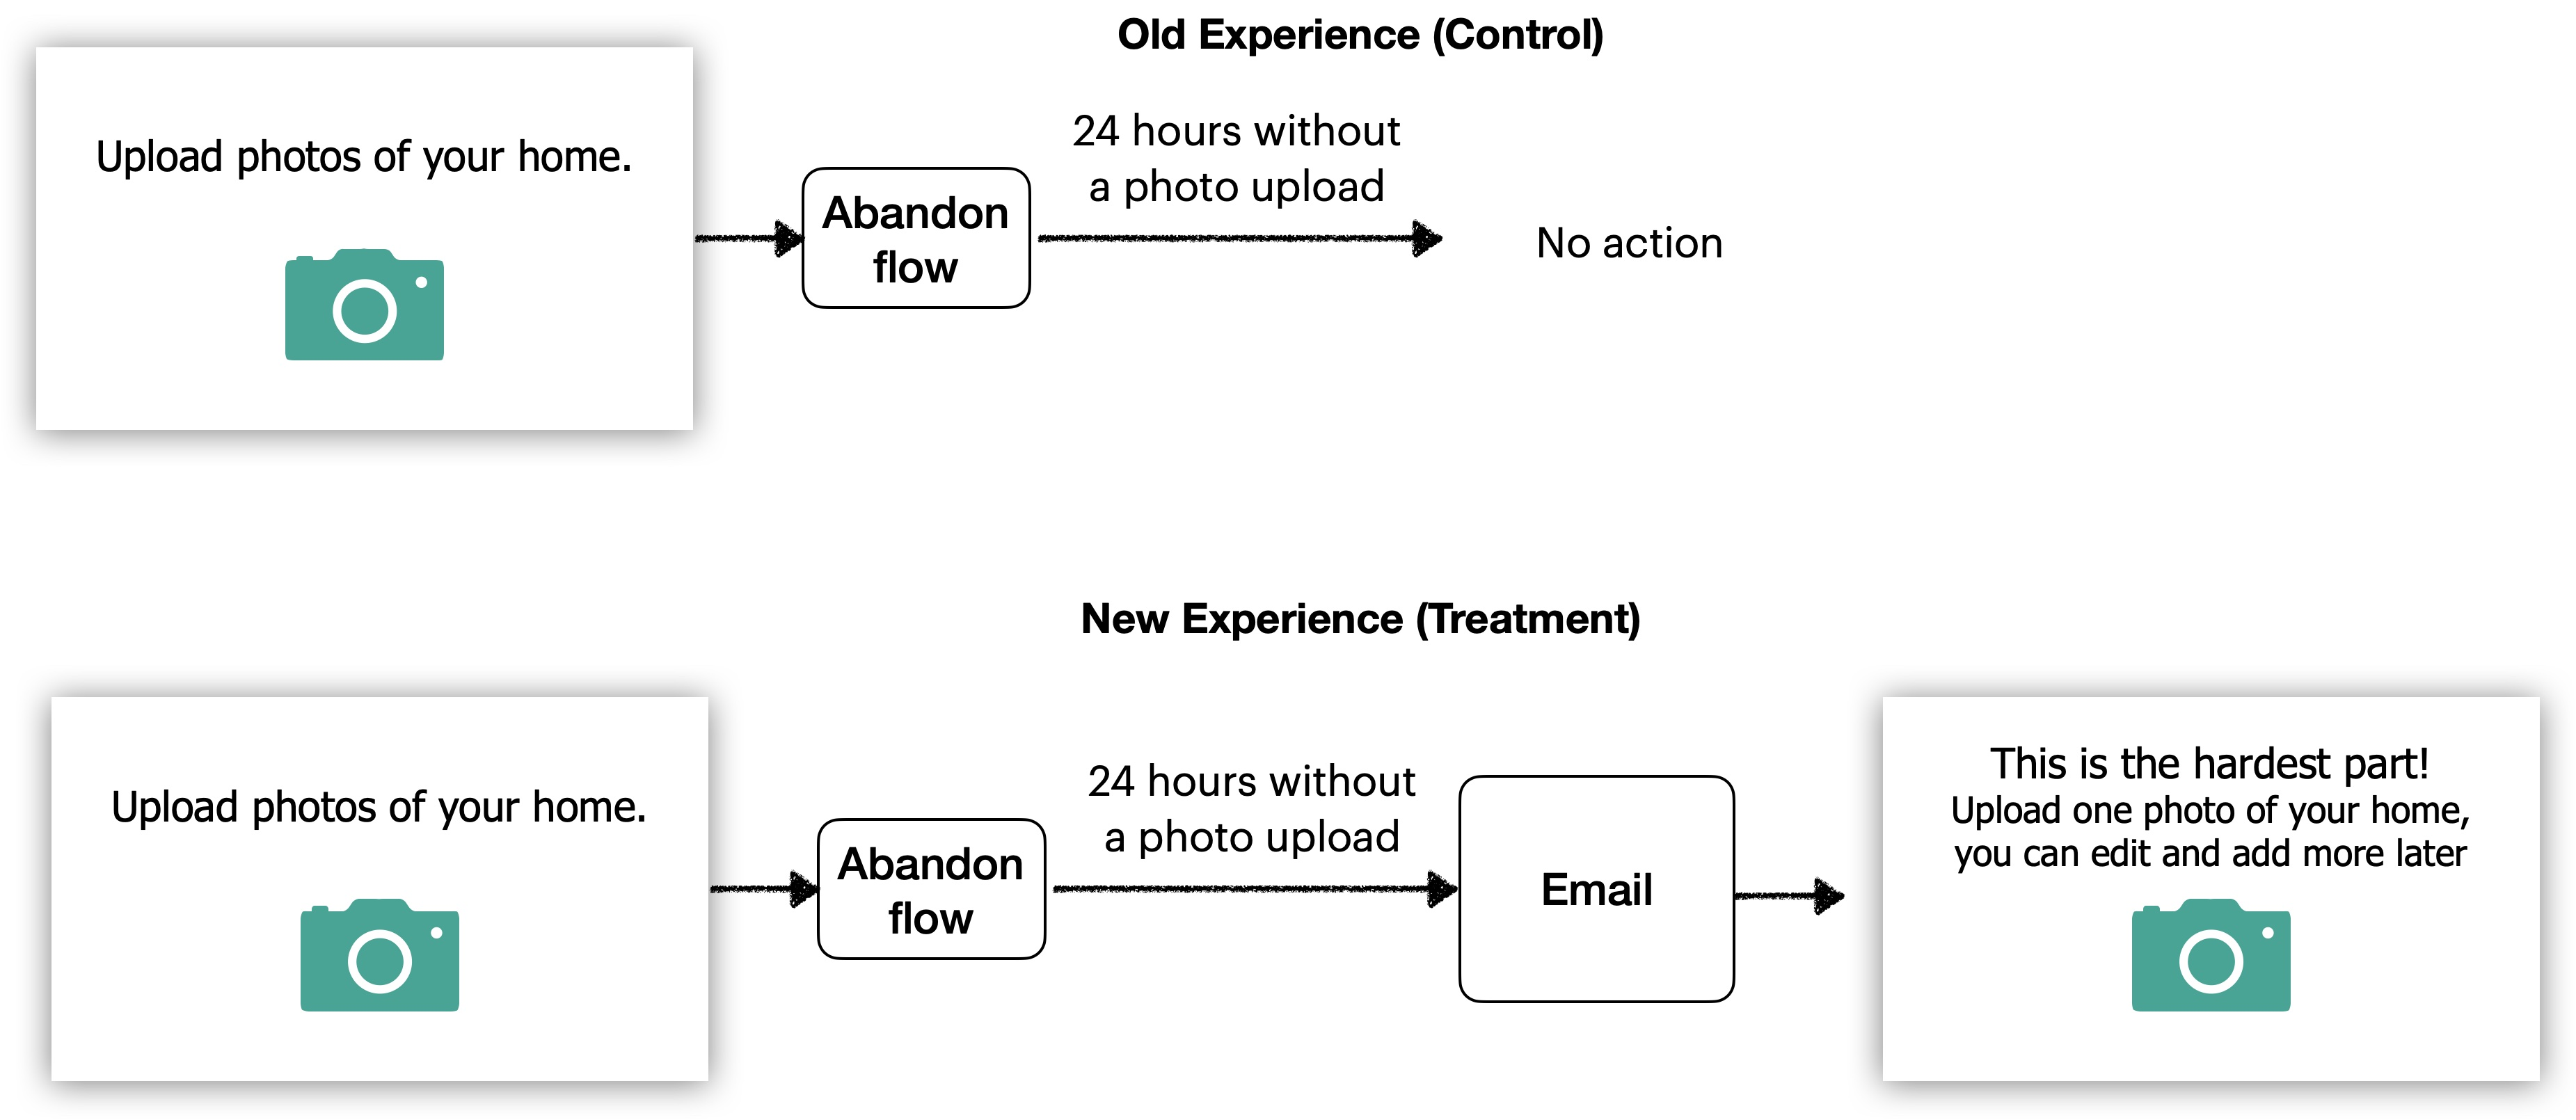

Again we provide you some details of the test design below.

Triggering Details: The test should be triggered when someone has abandoned the flow from the upload photos page and has not uploaded a photo within 24 hours of abandoning the flow. Note that the triggering should happen even if they don't receive an email.

Hypothesis: If we send an email and customzie the landing page for people who got stuck on the photo upload step, new booked listings will increase because more users will complete the flow.

### Task 2.a. Design: How long should the test run and how will the launch/ no launch decision be made?

Assume that there are 1000 new users visiting the triggering point each day and the cohort-book rate for that group is 10%. This is because we're subsetting to the users who exit the flow and they're unlikely to convert on their own. After all, they did leave the flow in the first place. PaM doesn't have a prior on how long she's willing to run it or how big of a change she expects, so please bring her some options.

You can use an online sample size calculate (e.g. Evan Miller's [sample size calculator](https://www.evanmiller.org/ab-testing/sample-size.html)).

## ANSWER 2.a

| Metric | Baseline Rate | Minimum Detectable Lift | Sample Size <br> Needed Per Variant | Days Needed <br> (1k daily)|
|-|-|-|-|-|
| New Booked Listings | 10% | 2% relative increase (to 10.2%) | 354,139 | 708|
| New Booked Listings | 10% | 5% relative increase (to 10.5%) | 56,885 | 114 |
| New Booked Listings | 10% | 10% relative increase (to 11%) | 14,313 | 29 |

Assumptions:
- 80% power
- 95% confidence

Given the above results, I recommend running the test for 5 weeks (35 days) to ensure sufficient statistical power for detecting a 10% relative increase. The sample size needed to detect an MDE less than this if time is a factor in launching this feature.

Decision criteria:
- Launch if new booked listings increases by 10% or more with statistical significance
- Do not launch otherwise

### Task 2.b. Analysis

After discussing the options with PaM, you collectively decided to run the test for 35 days to detect a 10% change or greater with a little buffer. Those in the control group who return to the flow probably need more time to publish and book than the average host, so you want to ensure you build in time to capture those conversions.

Please analyze the results and summarize the findings and recommendations below. The data has already been cleaned for you. Like with previous tasks, the table contains information for three milestones:

* new_active_listing - 1 if a user published their listing during experiment. Otherwise 0.
* new_booked_listing - 1 if a user received a guest booked on a new listing during the experiment. Otherwise 0.
* new_cancelled_listing - 1 if a user cancelled a new booking during the experiment. Otherwise 0.

We also provided some segmentation information for each user.
* continent - the continent for the host, either 'asia','north_america','south_america','australia','europe','africa'
* booked_previously - 1 if the host has been booked before the started the onboarding flow (because they hosted on other platforms like Airbnb). Otherwise 0.
* device - the device the host is using when starting the onboarding flow. Either 'android', 'ios' or 'web'.

Note: Only use a user segment when you have a reason to do so.

In [ ]:
df_upload_photos = pd.read_csv('/content/dataset_upload_photos.csv')

### Creating a function to check for Assignment Imbalance

In [ ]:
from scipy.stats import chi2_contingency

def ab_test_chi2(data_column):
    """
    Performs a Chi-squared test on A/B testing data where the groups are labeled 'control' and 'treatment'.

    :param data_column: Pandas Series with two possible values ('control' and 'treatment').
    :return: The p-value from the Chi-squared test.
    """

    if not isinstance(data_column, pd.Series):
        raise ValueError("The data_column must be a Pandas Series.")

    # Mapping 'control' to 0 and 'treatment' to 1
    data_column_mapped = data_column.map({'control': 0, 'treatment': 1})

    if data_column_mapped.isnull().any():
        raise ValueError("The data_column must contain only 'control' and 'treatment' values.")

    # Count the occurrences of control (0) and treatment (1)
    observed_counts = data_column_mapped.value_counts()

    # Assuming a 50/50 split for the expected counts
    total_count = observed_counts.sum()
    expected_counts = pd.Series([total_count / 2, total_count / 2], index=observed_counts.index)

    # Perform the Chi-squared test
    chi2, p_value, _, _ = chi2_contingency([observed_counts, expected_counts])

    return p_value, total_count, observed_counts


In [ ]:
p_value, total_count, observed_counts = ab_test_chi2(df_upload_photos['variant'])
print(f"Total Count: {total_count}")
print(f"Observed Count:\n{observed_counts}")
print(f"Chi-squared test p-value: {p_value}")

Total Count: 5596
Observed Count:
1    3672
0    1924
Name: variant, dtype: int64
Chi-squared test p-value: 1.1252788582715951e-62



### Looks like we have almost twice as many people assigned to the treatment variant. The chances of this happening assuming a 50:50 weighting are virtually impossible. This suggests that there is a serious error in this A/B test and that we will need to re-run it.


---

##### Hint - Click to unhide

Remember the two errors we talked about in class this week and how you know if they are present:
* [Assignment imbalance](https://.com/course/practical-ab-testing/v2/module/setup-errors#_clhv0h9j200003b7moycd4wbg)
* [Dilution](https://.com/course/practical-ab-testing/v2/module/setup-error-dilution#_clhv06v9s000i3b6rxqf5nkpo)

Do you see anything off here?

### What happened?
_**Warning**: this will give away the answer to the previous task._

You went to the engineer who implemented the A/B test and had them walk through how users were cohorted. Turns out, the triggering moment was not identical for the control and treatment group, which is the likely culprit of the assignment imbalance. It's a bummer, but everyone learned from the experience and you plan on starting a new test with the triggering moment fixed.

## Task 3: New map service for Africa

It is a known problem that the company you work with to confirm and locate the address of a home struggles a LOT in Africa. User research has found that hosts in Africa need to spend a substantial amount of time moving the pin to find their actual location from the suggested spot- if they find it at all. You hypothesize this is the primary reason conversion is so low through the maps section of the onboarding flow. A new player has come on the market, and the team wants to determine if using them helps with conversion through the maps section (see below). Since the change is on the backend, the UI would look mostly the same.

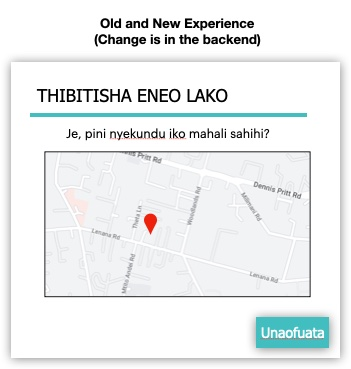

Triggering Moment: Users should be put in the test when they land on the maps page, if the address is in Africa.

Hypothesis: If we use the new service to confirm and locate address in Africa, new booked listings will increase because it will correctly identify the location in Africa and reduce friction for the host.

### Task 3.a. Design: How long should the test run and how will the launch/ no launch decision be made?

You can assume that about 500 new users from Africa arrive in the flow each day, and the cohort to book rate for that population is 12%. Note that prior to this page, the user enters in their address including the country.

The new service is significantly more expensive than the old one, and it might anger your existing vendor, so this change is only worth if it the relative increase is more than 10% for the impacted population. PaM told you they are fine running it up to 2 months because it's a really important decision, though of course, less is preferable if you can get enough signal in that time.

You can use an online sample size calculate (e.g. Evan Miller's [sample size calculator](https://www.evanmiller.org/ab-testing/sample-size.html)).

## ANSWER 3.a

| Metric | Baseline Rate | Minimum Detectable Lift | Sample Size <br> Needed Per Variant | Days Needed <br> (500 daily)|
|-|-|-|-|-|
| New Booked Listings | 12% | 10% relative increase (to 13.2%) | 11658 | 47 |

Assumptions:
- 80% power
- 95% confidence

Given the above results, I recommend running the test for 8 weeks (56 days) to ensure sufficient statistical power for detecting a 10% relative increase. This is within the 2 month (60 days) time constraint specified by PaM.

Decision criteria:
- Launch if new booked listings increases by 10% or more with statistical significance
- Do not launch otherwise

### Task 3.b. Test analysis

Please analyze the test and summarize the learnings and recommendations for PaM and the team below with the A/B test data provided. The data has already been cleaned for you. There is information for three milestones:

* new_active_listing - 1 if a user published their listing during experiment. Otherwise 0.
* new_booked_listing - 1 if a user received a guest booked on a new listing during the experiment. Otherwise 0.
* new_cancelled_listing - 1 if a user cancelled a new booking during the experiment. Otherwise 0.

We also provided some segmentation information for each user.
* continent - the continent for the host, either 'asia','north_america','south_america','australia','europe','africa'
* booked_previously - 1 if the host has been booked before the started the onboarding flow (because they have another home on TinyTravels). Otherwise 0.
* device - the device the host is using when starting the onboarding flow. Either 'android', 'ios' or 'web'.

Note: Only use a user segment when you have a reason to do so.

# ANSWER 3.B

In [ ]:
df_africa_map = pd.read_csv('/content/dataset_africa_map.csv')

In [ ]:
p_value, total_count, observed_counts = ab_test_chi2(df_africa_map['variant'])
print(f"Total Count: {total_count}")
print(f"Observed Count:\n{observed_counts}")
print(f"Chi-squared test p-value: {p_value}")

Total Count: 244986
Observed Count:
1    122645
0    122341
Name: variant, dtype: int64
Chi-squared test p-value: 0.6661477570731109


### Looks like we don't have any Assignment Imbalance issues here

In [ ]:
df_africa_map.groupby(['continent', 'variant'])["id_user"].nunique()

continent      variant  
africa         control      12233
               treatment    12266
asia           control       5543
               treatment     5480
australia      control       5483
               treatment     5486
europe         control      32952
               treatment    33225
north_america  control      55019
               treatment    55003
south_america  control      11111
               treatment    11185
Name: id_user, dtype: int64

### However, only users whose address was found to be in Africa were supposed to trigger the event of assigning them to a group in this A/B test. The above results clearly show that users across all continents were assigned to a group in this A/B test.

In [ ]:
df_africa = df_africa_map[df_africa_map['continent'] == 'africa']

In [ ]:
p_value, total_count, observed_counts = ab_test_chi2(df_africa['variant'])
print(f"Total Count: {total_count}")
print(f"Observed Count:\n{observed_counts}")
print(f"Chi-squared test p-value: {p_value}")

Total Count: 24499
Observed Count:
1    12266
0    12233
Name: variant, dtype: int64
Chi-squared test p-value: 0.8886231599645935


### Subsetting on only the African population, we can still proceed and yield valid results from this A/B test. It may also be interesting to see the results in other continents since we assumed that the issue of poor pin locations only existed for the continent of Africa. If this is truly the case, we should expect to see little to no change in NBL for the other continents.

### TARGET

In [ ]:
metric = 'new_booked_listing'
print(f"Analysis of {metric}")
pd.DataFrame(calculate_results(df_africa, metric),
             index=['rel diff','abs diff','pvalue','ci low','ci high']).T

Analysis of new_booked_listing


,rel diff,abs diff,pvalue,ci low,ci high
0,0.043883,0.011138,0.046725,0.000641,0.087125


In [ ]:
metric = 'new_booked_listing'
print(f"Analysis of {metric}")
custom_calculate_results(df_africa_map, metric, dimensions=["continent", "booked_previously", "device"])

Analysis of new_booked_listing


{'overall': None,
 'breakdown': {('continent', 'africa'): (0.04388287223129379,
   0.011138422159582051,
   0.04672541462095043,
   0.0006406117909760265,
   0.08712513267161157),
  ('continent', 'australia'): (0.06678951280018246,
   0.01609136356174376,
   0.05133943473855432,
   -0.00037455107837814234,
   0.13395357667874308),
  ('continent', 'europe'): (0.0034541949986634794,
   0.0008551627457846767,
   0.7989566759175012,
   -0.023126095448623374,
   0.030034485445950335),
  ('continent', 'north_america'): (-0.010905314780739873,
   -0.0027448117756354307,
   0.29333806163012205,
   -0.031245215431667285,
   0.00943458587018754),
  ('continent', 'south_america'): (0.014400583090011528,
   0.003675641584310385,
   0.5300764716667867,
   -0.03054759460763744,
   0.0593487607876605),
  ('continent', 'asia'): (-0.0113946561496608,
   -0.0029067371090781835,
   0.7258466035708975,
   -0.07507544843839156,
   0.05228613613906996),
  ('booked_previously', 0): (-0.0017525104163826624,
 

### These results suggest that the new algorithm is likely to improve pin locations in Africa and hence drive NBL but we may also see the same for listings in Australia

| Category                   | Rel Diff               | Abs Diff               | P-Value              | CI Low                | CI High             |
|----------------------------|------------------------|------------------------|----------------------|-----------------------|---------------------|
| continent, africa          | 0.04388287223129379    | 0.011138422159582051   | 0.04672541462095043  | 0.0006406117909760265 | 0.08712513267161157 |
| continent, australia       | 0.06678951280018246    | 0.01609136356174376    | 0.05133943473855432  | -0.00037455107837814234 | 0.13395357667874308 |
| continent, europe          | 0.0034541949986634794  | 0.0008551627457846767  | 0.7989566759175012   | -0.023126095448623374 | 0.030034485445950335 |
| continent, north_america   | -0.010905314780739873  | -0.0027448117756354307 | 0.29333806163012205  | -0.031245215431667285 | 0.00943458587018754 |
| continent, south_america   | 0.014400583090011528   | 0.003675641584310385   | 0.5300764716667867   | -0.03054759460763744  | 0.0593487607876605  |
| continent, asia            | -0.0113946561496608    | -0.0029067371090781835 | 0.7258466035708975   | -0.07507544843839156  | 0.05228613613906996 |
| booked_previously, 0       | -0.0017525104163826624 | -0.0004412369256749926 | 0.8219572657434792   | -0.017016538764569628 | 0.013511517931804301 |
| booked_previously, 1       | 0.028003805261698638   | 0.0069134073435361265  | 0.07702320070776096  | -0.0030352931433650573 | 0.059042903666762334 |
| device, android            | 0.006273342713777567   | 0.0015742823566214925  | 0.5089735475415579   | -0.0123436670251082   | 0.024890352452663335 |
| device, web                | 0.044144810790558306   | 0.01100383846685471    | 0.045118773755384756 | 0.0009627214283416921 | 0.08732690015277493 |
| device, ios                | -0.010595283709634995  | -0.0026593487841514996 | 0.36430641378210205  | -0.03348592033210931  | 0.012295352912839317 |


### GUARDRAIL

In [ ]:
metric = 'new_cancelled_listing'
print(f"Analysis of {metric}")
pd.DataFrame(calculate_results(df_africa, metric),
             index=['rel diff','abs diff','pvalue','ci low','ci high']).T

Analysis of new_cancelled_listing


,rel diff,abs diff,pvalue,ci low,ci high
0,0.189338,0.002492,0.101745,-0.037387,0.416063


In [ ]:
metric = 'new_cancelled_listing'
print(f"Analysis of {metric}")
custom_calculate_results(df_africa_map, metric, dimensions=["continent", "booked_previously", "device"])

Analysis of new_cancelled_listing


{'overall': None,
 'breakdown': {('continent', 'africa'): (0.18933819992242357,
   0.0024919030644576304,
   0.10174519837954958,
   -0.03738679395580929,
   0.4160631938006564),
  ('continent', 'australia'): (0.918950054684652,
   0.008379993203398248,
   0.00012809319640403588,
   0.44894921393261056,
   1.3889508954366934),
  ('continent', 'europe'): (0.4375848781266391,
   0.005258667508441037,
   1.8150015430230092e-08,
   0.2853480304290263,
   0.5898217258242519),
  ('continent', 'north_america'): (0.38929290725556387,
   0.004839716253708822,
   3.2148519162031865e-11,
   0.27433066643181026,
   0.5042551480793175),
  ('continent', 'south_america'): (0.5016269713382749,
   0.005823947376711139,
   0.00027930345402194434,
   0.2312951161190879,
   0.771958826557462),
  ('continent', 'asia'): (0.5700838871336746,
   0.00689078485259899,
   0.003419463564291735,
   0.1880235451951889,
   0.9521442290721605),
  ('booked_previously', 0): (0.3965702216414505,
   0.0048258366269897345

### The new algorithm seems to be driving increases in NCL for all continents but especially for europe and north america. The increase in africa is much less stat-sig

| Category                   | Rel Diff                | Abs Diff                | P-Value                    | CI Low                | CI High               |
|----------------------------|-------------------------|-------------------------|----------------------------|-----------------------|-----------------------|
| continent, africa          | 0.18933819992242357     | 0.0024919030644576304   | 0.10174519837954958        | -0.03738679395580929  | 0.4160631938006564    |
| continent, australia       | 0.918950054684652       | 0.008379993203398248    | 0.00012809319640403588     | 0.44894921393261056   | 1.3889508954366934    |
| continent, europe          | 0.4375848781266391      | 0.005258667508441037    | 1.8150015430230092e-08     | 0.2853480304290263    | 0.5898217258242519    |
| continent, north_america   | 0.38929290725556387     | 0.004839716253708822    | 3.2148519162031865e-11     | 0.27433066643181026   | 0.5042551480793175    |
| continent, south_america   | 0.5016269713382749      | 0.005823947376711139    | 0.00027930345402194434     | 0.2312951161190879    | 0.771958826557462     |
| continent, asia            | 0.5700838871336746      | 0.00689078485259899     | 0.003419463564291735       | 0.1880235451951889    | 0.9521442290721605    |
| booked_previously, 0       | 0.3965702216414505      | 0.0048258366269897345   | 5.17081379323042e-19       | 0.30935210841963645   | 0.48378833486326456   |
| booked_previously, 1       | 0.4946450989780523      | 0.005983853789926339    | 5.349695079897135e-08      | 0.3164419232313023    | 0.6728482747248022    |
| device, android            | 0.3710397122785542      | 0.004657824386354042    | 2.4898148333585064e-12     | 0.2672442429499042    | 0.4748351816072042    |
| device, web                | 0.43214570063694263     | 0.005069157778732465    | 0.0006928110202188381      | 0.18241541406327144   | 0.6818759872106138    |
| device, ios                | 0.485107833901987       | 0.005661653218053378    | 2.703677203175846e-12      | 0.3491964534939676    | 0.6210192143100064    |


---
### Summary
The implementation of assigning users to this A/B test seems to have missed that this was only meant to apply to the African cohort. Subsetting the total population to this cohort we observe only a 4% relative increase in NBL which is substantially less than the 10% specified in the decision criteria.

I therefore recommend sticking with our current pin algorithm.


##### Hint: Click to expand

Remember the two errors we talked about in class this week and how you know if they are present:
* [Assignment imbalance](https://.com/course/practical-ab-testing/v2/module/setup-errors#_clhv0h9j200003b7moycd4wbg)
* [Dilution](https://.com/course/practical-ab-testing/v2/module/setup-error-dilution#_clhv06v9s000i3b6rxqf5nkpo)

Do you see anything off here?

### What happened?
_**Warning**: this will give away the answer to the previous task._

You asked the engineer who implemented the test: "Might we have missed the filter for only cohorting users with African addresses?". Turns out, yup. Since the test has run its course, you decided to subset to the relevant population and use that as the result, rather than starting a new test from scratch. The result you found was not above the threshold specified by PaM, so everyone decided to keep them on the old map service, for now. The result being positive sparked a broader conversation about if there might other negative business impacts- bad guest experience, support tickets, etc., that should be factored into the decision beyond a simple increase in NBL. You're getting a little uncomfortable, the test was not designed to take those into account. But in the end, the business partners decide that they'll monitor the support tickets around this issue and revisit the decision if it seems to be an issue in the future.

## Bonus 1: Break out into two pages

You've noticed that only a few hosts are selecting amenities, and with offline correlation analysis, you found that amenities are connected to the likelihood of being booked. The team hypothesizes that hosts might not be selecting the amenities because it's low on a long page, so they want to test putting it on its own page.

See the UI change below.

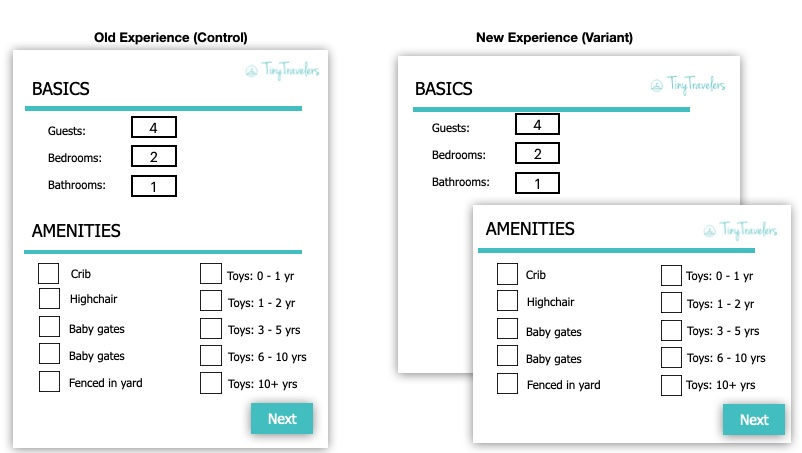

### Bonus 1.a. Test design by answering the following...

#### Bonus 1.a.i. When should the test be triggered?

Since the control has both Basics and Amenties on the same page, the assignment must happen immediately on page load, before the user starts interacting with the page.

Users assigned to the control group will load the full Basics + Amenties sections meanwhile users in the treatment will separate these 2 sections into 2 seperate pages.

#### Bonus 1.a.ii. What is the hypothesis?

The hypothesis is that having amenties on it's own page will mean potential hosts will be more likely to add this information to their listing which will increase NBL^*.

^* *An offline correlational analysis suggested that listings with information of amenties provided increased NBL*

#### Bonus 1.a.iii. How long should the test run and how will the launch/ no launch decision be made?

You can assume that about 5K new users arrive in the flow each day. And the cohort to book rate is 20%. You can use an online sample size calculate (e.g. Evan Miller's [sample size calculator](https://www.evanmiller.org/ab-testing/sample-size.html)).

## ANSWER 4.a.ii

| Metric | Baseline Rate | Minimum Detectable Lift | Sample Size <br> Needed Per Variant | Days Needed <br> (5k daily)|
|-|-|-|-|-|
| New Booked Listings | 20% | 3% relative increase (to 20.6%) | 70,001 | 28 |
| New Booked Listings | 20% | 5% relative increase (to 21%) | 25,255 | 11 |
| New Booked Listings | 20% | 10% relative increase (to 22%) | 6,347 | 3 |

Assumptions:
- 80% power
- 95% confidence

Given the above results, I recommend running the test for 2 weeks (14 days) to ensure sufficient statistical power for detecting a 5% relative increase.

Decision criteria:
- Launch if new booked listings increases by any % with statistical significance since there are no downsides to splitting this into 2 pages
- Do not launch otherwise

### Bonus 1.b. Test analysis

Please analyze the test and summarize the learnings and recommendations for PaM and the team below with the A/B test data provided. The data has already been cleaned for you. There is information for three milestones:

* new_active_listing - 1 if a user published their listing during experiment. Otherwise 0.
* new_booked_listing - 1 if a user received a guest booked on a new listing during the experiment. Otherwise 0.
* new_cancelled_listing - 1 if a user cancelled a new booking during the experiment. Otherwise 0.

We also provided some segmentation information for each user.
* continent - the continent for the host, either 'asia','north_america','south_america','australia','europe','africa'
* booked_previously - 1 if the host has been booked before the started the onboarding flow (because they have another home on TinyTravels). Otherwise 0.
* device - the device the host is using when starting the onboarding flow. Either 'android', 'ios' or 'web'.

_Basic_: What happened at a high-level to the target (new booked listings) and guardrail (new cancelled listings) and do you recommend a launch or not based on that?

_Bonus_: Given unlimited time, what follow-up analysis and testing might you do? (No coding on this- just thinking).

In [ ]:
df_split_page = pd.read_csv('/content/dataset_split_page.csv') # Load data

### Possible assignment imbalance, lets check the other dimesnions

In [ ]:
p_value, total_count, observed_counts = ab_test_chi2(df_split_page['variant'])
print(f"Total Count: {total_count}")
print(f"Observed Count:\n{observed_counts}")
print(f"Chi-squared test p-value: {p_value}")

Total Count: 139498
Observed Count:
1    70220
0    69278
Name: variant, dtype: int64
Chi-squared test p-value: 0.07513544441773315


### Looks just about okay and since we are above the 0.05 significance level I'm willing to give engineering the benefit of the doubt that there is no assignment imbalance here ;)

In [ ]:
df_split_page.groupby(["continent", "variant"])["id_user"].nunique()

continent      variant  
africa         control       6231
               treatment     6329
asia           control       3190
               treatment     3186
australia      control       3086
               treatment     3226
europe         control      19010
               treatment    19219
north_america  control      31540
               treatment    31819
south_america  control       6221
               treatment     6441
Name: id_user, dtype: int64

### Target

In [ ]:
metric = 'new_booked_listing'
print(f"Analysis of {metric}")
pd.DataFrame(calculate_results(df_split_page, metric),
             index=['rel diff','abs diff','pvalue','ci low','ci high']).T

Analysis of new_booked_listing


,rel diff,abs diff,pvalue,ci low,ci high
0,0.047285,0.003938,0.008456,0.012097,0.082473


### Guardrail

In [ ]:
metric = 'new_cancelled_listing'
print(f"Analysis of {metric}")
pd.DataFrame(calculate_results(df_split_page, metric),
             index=['rel diff','abs diff','pvalue','ci low','ci high']).T

Analysis of new_cancelled_listing


,rel diff,abs diff,pvalue,ci low,ci high
0,0.074152,0.000181,0.501356,-0.141951,0.290255


**High Level Results**

- For the target metric (new booked listings), the treatment group saw a **5% relative** increase compared to the control group. This was statistically significant (p-value < 0.05).
- For the guardrail metric (new cancelled listings), there was no detectable difference between the groups.

**Recommendation**
- Based on a 5% significant increase in the target metric and no negative impact on the guardrail, I recommend the team launch this change.
